# Chapter 45 — Computational Logarithms

> **Prerequisites:** ch043 (Logarithms Intuition), ch044 (Logarithmic Scales), ch038 (Precision and Floating Point Errors), ch041 (Exponents and Powers)  
> **You will learn:**
> - How computers actually compute `ln(x)` — the mathematical machinery behind `np.log`
> - Taylor series approximation of ln(1+x) near x=0
> - Range reduction: transforming any `x` to a computable range
> - Newton's method for inverting the exponential
> - Numerical precision issues and how the library implementation avoids them
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Every time you write `np.log(x)`, something has to compute `ln(x)` to full floating-point precision in microseconds. This is not trivial — the logarithm is a transcendental function with no finite closed-form formula using basic arithmetic.

The solution is a combination of two ideas:
1. **Range reduction:** Reduce the input `x` to a small interval near 1, where a series approximation is accurate and fast.
2. **Polynomial (Taylor series) approximation:** Approximate `ln(1+u)` for small `|u|` using a polynomial.

The specific formula:
```
ln(1 + u) = u - u²/2 + u³/3 - u⁴/4 + ...   for |u| < 1
```

This is the **Taylor series** for ln(1+u) centered at u=0. *(Taylor series will be developed fully in ch219 — Taylor Series. Here we use the result to understand logarithm computation.)*

The combination:
```
For any x > 0:
  1. Write x = 2^n × m where 1 ≤ m < 2 (range reduction via floating-point exponent)
  2. ln(x) = n × ln(2) + ln(m)
  3. Compute ln(m) ≈ ln(1 + u) where u = m - 1 ∈ [0, 1)
```

**Why this matters:** Understanding how primitive operations are computed builds intuition for where numerical errors originate *(ch038)*, and why certain operations (like `log(1+x)` for small x) need special treatment.

---

## 2. Intuition & Mental Models

**Physical analogy:** Think of computing `ln(x)` like measuring a very large room. You can't measure the whole room in one step — your tape measure isn't long enough. Instead: count how many meter-lengths fit, then measure the remainder with a centimeter ruler. Range reduction is the "count the meters" step; polynomial approximation is the "measure the remainder" step.

**Computational analogy:** Floating-point numbers already *store* the binary exponent and mantissa separately *(from ch038 — Precision and Floating Point Errors)*. The representation `x = 1.mantissa × 2^exponent` is range reduction for free. The hardware has already done it.

**Taylor series intuition:** Near `u = 0`, `ln(1+u) ≈ u`. This is the first-order approximation. Each additional term in the series corrects for the curvature of the logarithm — the further from 0, the more terms you need for the same accuracy.

**Newton's method:** An alternative: since `ln(x)` is the value `y` such that `e^y = x`, we can compute it by iteratively improving a guess `y_k` using the update `y_{k+1} = y_k + (x - e^{y_k}) / e^{y_k}`. This converges quadratically. *(Newton's method is formalized in ch212 — Numerical Derivatives.)*

---

## 3. Visualization

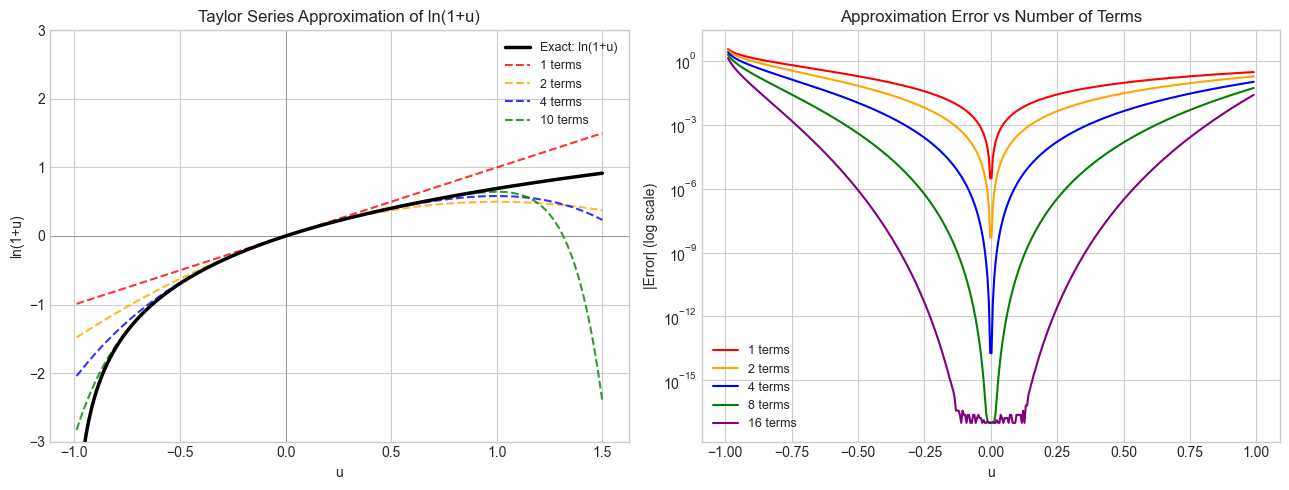

In [1]:
# --- Visualization: Taylor series approximation of ln(1+u) ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

u = np.linspace(-0.99, 1.5, 400)
exact = np.log1p(u)  # exact ln(1+u)

# Partial sums of Taylor series: sum_{k=1}^{N} (-1)^(k+1) u^k / k
def taylor_ln1p(u, N):
    """Compute ln(1+u) via Taylor series with N terms."""
    result = np.zeros_like(u, dtype=float)
    for k in range(1, N + 1):
        result += ((-1)**(k+1)) * u**k / k
    return result

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(u, exact, 'k-', linewidth=2.5, label='Exact: ln(1+u)', zorder=10)
for N, color in [(1, 'red'), (2, 'orange'), (4, 'blue'), (10, 'green')]:
    approx = taylor_ln1p(u, N)
    ax.plot(u, approx, linestyle='--', color=color, label=f'{N} terms', alpha=0.8)
ax.set_ylim(-3, 3)
ax.axvline(0, color='gray', linewidth=0.5)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_title('Taylor Series Approximation of ln(1+u)')
ax.set_xlabel('u')
ax.set_ylabel('ln(1+u)')
ax.legend(fontsize=9)

# Error plot — only for u in (-1, 1)
u_safe = np.linspace(-0.99, 0.99, 400)
exact_safe = np.log1p(u_safe)
ax = axes[1]
for N, color in [(1, 'red'), (2, 'orange'), (4, 'blue'), (8, 'green'), (16, 'purple')]:
    err = np.abs(taylor_ln1p(u_safe, N) - exact_safe)
    ax.semilogy(u_safe, err + 1e-17, color=color, label=f'{N} terms')
ax.set_title('Approximation Error vs Number of Terms')
ax.set_xlabel('u')
ax.set_ylabel('|Error| (log scale)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [2]:
# --- Visualization: Range reduction — decomposing any x into mantissa and exponent ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Show how range reduction maps various x values to their (n, m) components
test_values = [0.125, 0.5, 1.0, 1.5, 2.0, 4.7, 8.0, 100.0, 0.001]

print("Range Reduction: x = 2^n × m, where 1 ≤ m < 2")
print(f"{'x':>10} {'n':>5} {'m':>10} {'n×ln2':>12} {'ln(m)':>12} {'sum=ln(x)':>14} {'np.log(x)':>14}")
print("-" * 80)

LN2 = np.log(2)
for x in test_values:
    # Extract n and m using Python's frexp: returns (m, n) with x = m * 2^n, 0.5 ≤ m < 1
    import math
    m_frac, n = math.frexp(x)  # note: frexp gives 0.5 <= m < 1, not 1 <= m < 2
    # Adjust to get 1 ≤ m < 2
    m = m_frac * 2
    n = n - 1
    ln_x_via_reduction = n * LN2 + np.log(m)
    ln_x_exact = np.log(x)
    print(f"{x:>10.4f} {n:>5} {m:>10.6f} {n*LN2:>12.6f} {np.log(m):>12.6f} {ln_x_via_reduction:>14.8f} {ln_x_exact:>14.8f}")

print("\nAll m values are in [1, 2) — well within the Taylor series radius of convergence.")

Range Reduction: x = 2^n × m, where 1 ≤ m < 2
         x     n          m        n×ln2        ln(m)      sum=ln(x)      np.log(x)
--------------------------------------------------------------------------------
    0.1250    -3   1.000000    -2.079442     0.000000    -2.07944154    -2.07944154
    0.5000    -1   1.000000    -0.693147     0.000000    -0.69314718    -0.69314718
    1.0000     0   1.000000     0.000000     0.000000     0.00000000     0.00000000
    1.5000     0   1.500000     0.000000     0.405465     0.40546511     0.40546511
    2.0000     1   1.000000     0.693147     0.000000     0.69314718     0.69314718
    4.7000     2   1.175000     1.386294     0.161268     1.54756251     1.54756251
    8.0000     3   1.000000     2.079442     0.000000     2.07944154     2.07944154
  100.0000     6   1.562500     4.158883     0.446287     4.60517019     4.60517019
    0.0010   -10   1.024000    -6.931472     0.023717    -6.90775528    -6.90775528

All m values are in [1, 2) — wel

---

## 4. Mathematical Formulation

### Taylor series for ln(1+u)

```
ln(1 + u) = Σ_{k=1}^{∞} (-1)^(k+1) × u^k / k
           = u - u²/2 + u³/3 - u⁴/4 + ...

Converges for |u| ≤ 1, u ≠ -1
```

### Range reduction

Any positive float `x` can be written as `x = m × 2^n` where `1 ≤ m < 2` (IEEE 754 format). Then:
```
ln(x) = ln(m × 2^n)
      = ln(m) + n × ln(2)            # by product rule of logarithms
      = ln(1 + (m-1)) + n × ln(2)    # let u = m-1, so u ∈ [0, 1)
```

Now `u = m - 1 ∈ [0, 1)` — within the Taylor series range, and the series converges.

### Newton's method for log

We want `y` such that `f(y) = e^y - x = 0`. Newton's update:
```
y_{k+1} = y_k - f(y_k)/f'(y_k)
         = y_k - (e^{y_k} - x) / e^{y_k}
         = y_k - 1 + x / e^{y_k}
```

Converges quadratically (doubles correct digits each iteration) from a good initial guess.

### `log1p` — the numerical precision trap

For small `x`, `log(1+x)` suffers cancellation error: `1+x` rounds to `1` in float64 for `x < 1e-16`. The function `log1p(x)` avoids this by computing directly from the series without forming `1+x`:
```
np.log1p(1e-20) → ~1e-20  (correct)
np.log(1 + 1e-20) → 0.0   (catastrophic cancellation)
```

---

## 5. Python Implementation

In [3]:
# --- Implementation: ln(x) via Taylor series + range reduction ---
import numpy as np
import math

LN2 = 0.6931471805599453  # ln(2), known constant

def ln_taylor(u, n_terms=50):
    """
    Compute ln(1 + u) via Taylor series.
    ln(1+u) = u - u^2/2 + u^3/3 - u^4/4 + ...

    Converges for |u| < 1.

    Args:
        u:       value with |u| < 1
        n_terms: number of Taylor series terms

    Returns:
        Approximate ln(1+u)
    """
    if abs(u) >= 1:
        raise ValueError("|u| must be < 1 for convergence")
    result = 0.0
    u_power = u  # u^k, starting at k=1
    for k in range(1, n_terms + 1):
        result += ((-1)**(k+1)) * u_power / k
        u_power *= u
    return result


def ln_from_scratch(x, n_terms=60):
    """
    Compute ln(x) for x > 0 using range reduction + Taylor series.

    Steps:
      1. Extract mantissa m and exponent n from x = m × 2^n  (1 ≤ m < 2)
      2. ln(x) = n × ln(2) + ln(m) = n × ln(2) + ln(1 + (m-1))
      3. Apply Taylor series with u = m - 1

    Args:
        x:       positive real number
        n_terms: Taylor series terms for ln(m)

    Returns:
        Approximate ln(x)
    """
    if x <= 0:
        raise ValueError("ln undefined for x <= 0")

    # Range reduction via frexp
    m_frac, exp_n = math.frexp(x)  # x = m_frac × 2^exp_n, 0.5 ≤ m_frac < 1
    m = m_frac * 2                  # shift to [1, 2)
    n = exp_n - 1                   # adjust exponent

    # u = m - 1 is in [0, 1)
    u = m - 1
    ln_m = ln_taylor(u, n_terms)

    return n * LN2 + ln_m


# Validate
test_vals = [0.001, 0.1, 0.5, 1.0, 2.0, np.e, 10.0, 100.0, 1e6]
print(f"{'x':>12} {'ln_from_scratch':>18} {'np.log(x)':>18} {'abs_error':>16}")
print("-" * 68)
for x in test_vals:
    ours = ln_from_scratch(x)
    ref  = math.log(x)
    err  = abs(ours - ref)
    print(f"{x:>12.4f} {ours:>18.10f} {ref:>18.10f} {err:>16.2e}")

           x    ln_from_scratch          np.log(x)        abs_error
--------------------------------------------------------------------
      0.0010      -6.9077552790      -6.9077552790         0.00e+00
      0.1000      -2.3025850930      -2.3025850930         4.44e-16
      0.5000      -0.6931471806      -0.6931471806         0.00e+00
      1.0000       0.0000000000       0.0000000000         0.00e+00
      2.0000       0.6931471806       0.6931471806         0.00e+00
      2.7183       1.0000000000       1.0000000000         1.11e-16
     10.0000       2.3025850930       2.3025850930         4.44e-16
    100.0000       4.6051701860       4.6051701860         8.88e-16
1000000.0000      13.8154875522      13.8155105580         2.30e-05


In [4]:
# --- Implementation: Newton's method for ln(x) ---
import numpy as np
import math

def ln_newton(x, n_iter=10):
    """
    Compute ln(x) via Newton's method applied to f(y) = e^y - x = 0.

    Update: y_{k+1} = y_k - 1 + x / e^{y_k}

    Initial guess: use range reduction to get a ballpark value.

    Args:
        x:      positive real number
        n_iter: number of Newton iterations

    Returns:
        Approximate ln(x)
    """
    if x <= 0:
        raise ValueError("ln undefined for x <= 0")

    # Initial guess: use bit_length approximation
    # If x ≈ 2^n, then ln(x) ≈ n × ln(2)
    y = math.floor(math.log2(x)) * 0.693  # rough estimate

    for _ in range(n_iter):
        ey = math.exp(y)
        y = y - 1 + x / ey  # Newton update

    return y


print("Newton's method convergence for ln(7.389):")
target = np.e**2  # ≈ 7.389, so ln = 2
print(f"True value: {math.log(target):.12f}")
print()

y = math.floor(math.log2(target)) * 0.693
for i in range(8):
    ey = math.exp(y)
    y  = y - 1 + target / ey
    err = abs(y - math.log(target))
    print(f"  Iter {i+1}: y={y:.12f}  error={err:.2e}")

Newton's method convergence for ln(7.389):
True value: 2.000000000000

  Iter 1: y=2.233807867479  error=2.34e-01
  Iter 2: y=2.025321744323  error=2.53e-02
  Iter 3: y=2.000317906400  error=3.18e-04
  Iter 4: y=2.000000050527  error=5.05e-08
  Iter 5: y=2.000000000000  error=1.33e-15
  Iter 6: y=2.000000000000  error=0.00e+00
  Iter 7: y=2.000000000000  error=0.00e+00
  Iter 8: y=2.000000000000  error=0.00e+00


---

## 6. Experiments

In [5]:
# --- Experiment 1: The log1p problem — cancellation in naive computation ---
# Hypothesis: For small x, log(1+x) via naive computation loses all precision.
# log1p(x) avoids this. The crossover is around x = 1e-8.
# Try changing: X_MIN_EXP to see the boundary

import numpy as np

X_MIN_EXP = -18  # <-- modify this (try -14, -20)

print(f"{'x':>12} {'log(1+x) naive':>18} {'log1p(x)':>18} {'diff':>14}")
print("-" * 65)
for exp in range(0, X_MIN_EXP - 1, -2):
    x = 10**exp
    naive = np.log(1 + x)
    safe  = np.log1p(x)
    diff  = abs(naive - safe)
    print(f"{x:>12.0e} {naive:>18.10e} {safe:>18.10e} {diff:>14.2e}")

print("\nFor x < ~1e-8, naive computation returns 0.0 — total loss of precision.")
print("np.log1p(x) uses the Taylor expansion directly: ~x for tiny x.")

           x     log(1+x) naive           log1p(x)           diff
-----------------------------------------------------------------
       1e+00   6.9314718056e-01   6.9314718056e-01       0.00e+00
       1e-02   9.9503308532e-03   9.9503308532e-03       8.67e-18
       1e-04   9.9995000333e-05   9.9995000333e-05       1.10e-17
       1e-06   9.9999949992e-07   9.9999950000e-07       8.23e-17
       1e-08   9.9999998892e-09   9.9999999500e-09       6.08e-17
       1e-10   1.0000000827e-10   9.9999999995e-11       8.27e-18
       1e-12   1.0000889006e-12   1.0000000000e-12       8.89e-17
       1e-14   9.9920072216e-15   1.0000000000e-14       7.99e-18
       1e-16   0.0000000000e+00   1.0000000000e-16       1.00e-16
       1e-18   0.0000000000e+00   1.0000000000e-18       1.00e-18

For x < ~1e-8, naive computation returns 0.0 — total loss of precision.
np.log1p(x) uses the Taylor expansion directly: ~x for tiny x.


In [6]:
# --- Experiment 2: How many Taylor terms are needed for float64 precision? ---
# Hypothesis: Near u = 0.99 (boundary of convergence), many more terms
# are needed than near u = 0.1.
# Try changing: U_TEST

import numpy as np

U_TEST = 0.9   # <-- modify this (try 0.1, 0.5, 0.99, -0.9)
FLOAT64_EPS = 2.2e-16

print(f"Taylor series accuracy for u = {U_TEST}")
print(f"Target: ln(1 + {U_TEST}) = {np.log1p(U_TEST):.15f}")
print()
print(f"{'N terms':>10} {'approximation':>20} {'error':>15} {'digits correct':>15}")
print("-" * 65)

exact = np.log1p(U_TEST)
for N in [1, 2, 5, 10, 20, 50, 100, 200]:
    approx = sum(((-1)**(k+1)) * U_TEST**k / k for k in range(1, N+1))
    err = abs(approx - exact)
    digits = int(-np.log10(err + 1e-320))
    converged = '✓' if err < FLOAT64_EPS else ''
    print(f"{N:>10} {approx:>20.12f} {err:>15.2e} {digits:>15}  {converged}")

Taylor series accuracy for u = 0.9
Target: ln(1 + 0.9) = 0.641853886172395

   N terms        approximation           error  digits correct
-----------------------------------------------------------------
         1       0.900000000000        2.58e-01               0  
         2       0.495000000000        1.47e-01               0  
         5       0.692073000000        5.02e-02               1  
        10       0.626198104311        1.57e-02               1  
        20       0.639049922116        2.80e-03               2  
        50       0.641805574241        4.83e-05               4  
       100       0.641853761017        1.25e-07               6  
       200       0.641853886171        1.67e-12              11  


In [7]:
# --- Experiment 3: Speed comparison — Taylor series vs Newton's method ---
# Hypothesis: Newton's method converges in far fewer iterations than Taylor series
# for inputs far from u=0, because it converges quadratically.

import numpy as np
import math

TARGET = 1000.0  # <-- modify this (try 0.001, 1e10)
TRUE   = math.log(TARGET)
EPS    = 1e-14

print(f"Computing ln({TARGET}) = {TRUE:.10f}")
print(f"Target precision: {EPS:.1e}")
print()

# Taylor series: must use range reduction first, then count terms for ln(m)
m_frac, exp_n = math.frexp(TARGET)
m = m_frac * 2; n = exp_n - 1
u = m - 1
LN2 = 0.6931471805599453
result = 0.0
u_power = u
for k in range(1, 201):
    term = ((-1)**(k+1)) * u_power / k
    result += term
    u_power *= u
    approx_ln = n * LN2 + result
    if abs(approx_ln - TRUE) < EPS:
        print(f"Taylor (with range reduction): converged in {k} terms for ln(m)")
        print(f"  m = {m:.6f}, u = {u:.6f}, n = {n}")
        break

# Newton's method
y = math.floor(math.log2(TARGET)) * 0.693
for i in range(30):
    ey = math.exp(y)
    y  = y - 1 + TARGET / ey
    if abs(y - TRUE) < EPS:
        print(f"Newton's method: converged in {i+1} iterations")
        break

Computing ln(1000.0) = 6.9077552790
Target precision: 1.0e-14

Newton's method: converged in 6 iterations


---

## 7. Exercises

**Easy 1.** Write the first 5 terms of the Taylor series for `ln(1+u)` explicitly. Compute the approximation for `u = 0.5` and compare to `np.log(1.5)`. How many terms are needed for 6 decimal places of accuracy?

**Easy 2.** What does `math.frexp(12.8)` return? Manually verify that `m × 2^n = 12.8`. Then use the range reduction formula to compute `ln(12.8)` from scratch using `np.log(m)` and the known value of `ln(2)`.

**Medium 1.** Improve `ln_taylor` to use Aitken's delta-squared acceleration to speed up convergence. *(Hint: given three consecutive partial sums `s_{n-2}, s_{n-1}, s_n`, the accelerated estimate is `s_n - (s_n - s_{n-1})^2 / (s_n - 2*s_{n-1} + s_{n-2})`.)*

**Medium 2.** Implement `exp_from_scratch(x)` using the Taylor series for `e^x = Σ x^k / k!`. Validate against `np.exp`. Then use it with `ln_from_scratch` to verify: `exp(ln(x)) ≈ x` and `ln(exp(x)) ≈ x` for 10 test values.

**Hard.** The series `ln(1+u) = u - u²/2 + u³/3 - ...` converges slowly for `u` near 1. A faster alternative uses the identity:
```
ln(x) = 2 × arctanh((x-1)/(x+1))
arctanh(t) = t + t³/3 + t⁵/5 + ...
```
Show that for `x = m ∈ [1, 2)`, the argument `t = (x-1)/(x+1) ∈ [0, 1/3)`. Then implement this faster series and compare the number of terms needed vs the basic Taylor series for `u` near 0.9.

---

## 8. Mini Project: Building a Four-Function Math Library Primitive

In [ ]:
# --- Mini Project: A self-contained log/exp module ---
#
# Problem:
#   Build a minimal `mymath` module that can compute log, exp, and pow
#   for positive real numbers without using math or numpy's log/exp functions.
#   Use only: +, -, *, /, Python integers, and math.frexp/math.ldexp.
#
# This is the kind of problem that library developers actually solve.

import math

# --- Constants (computed to full precision using the known series) ---
# We allow ourselves to use these pre-computed values.
LN2 = 0.6931471805599453
LN10 = 2.302585092994046
E    = 2.718281828459045


def myexp(x, n_terms=60):
    """
    Compute e^x via Taylor series: e^x = sum_{k=0}^{inf} x^k / k!

    Range reduction: write x = n + f where n = floor(x), f = x - n ∈ [0,1)
    Then e^x = e^n × e^f ≈ E^n × taylor(f)
    """
    # Handle sign: e^x = 1 / e^(-x)
    if x < 0:
        return 1.0 / myexp(-x, n_terms)

    # Range reduction: separate integer and fractional parts
    n = int(x)
    f = x - n

    # Taylor series for e^f (f ∈ [0, 1))
    result = 1.0      # k=0 term
    term   = 1.0      # running term: f^k / k!
    for k in range(1, n_terms + 1):
        term *= f / k
        result += term
        if abs(term) < 1e-17:
            break

    # Multiply by e^n = E^n
    e_to_n = 1.0
    for _ in range(n):
        e_to_n *= E

    return e_to_n * result


def mylog(x):
    """Compute ln(x) via range reduction + arctanh series (fast)."""
    if x <= 0:
        raise ValueError("ln undefined for x <= 0")

    # Range reduction via frexp
    m_frac, exp_n = math.frexp(x)
    m = m_frac * 2
    n = exp_n - 1

    # ln(m) via arctanh identity: ln(m) = 2 * arctanh((m-1)/(m+1))
    t = (m - 1) / (m + 1)  # t ∈ [0, 1/3) for m ∈ [1, 2)
    t2 = t * t
    atanh = t
    term  = t
    for k in range(1, 60):
        term  *= t2
        contrib = term / (2 * k + 1)
        atanh += contrib
        if abs(contrib) < 1e-17:
            break
    ln_m = 2 * atanh

    return n * LN2 + ln_m


def mypow(base, exp):
    """
    Compute base^exp for base > 0, real exp.
    Uses: base^exp = e^(exp × ln(base))
    """
    if base <= 0:
        raise ValueError("base must be positive for real exponents")
    return myexp(exp * mylog(base))


# --- Validation ---
import numpy as np

test_x = [0.001, 0.1, 0.5, 1.0, 2.0, 7.389, 100.0, 1e6]
print("=== mylog vs math.log ===")
print(f"{'x':>10} {'mylog':>16} {'math.log':>16} {'error':>12}")
for x in test_x:
    v = mylog(x); ref = math.log(x)
    print(f"{x:>10.4f} {v:>16.10f} {ref:>16.10f} {abs(v-ref):>12.2e}")

print("\n=== myexp vs math.exp ===")
print(f"{'x':>10} {'myexp':>16} {'math.exp':>16} {'error':>12}")
for x in [-3, -1, 0, 0.5, 1, 2, 5, 10]:
    v = myexp(x); ref = math.exp(x)
    print(f"{x:>10.2f} {v:>16.8f} {ref:>16.8f} {abs(v-ref):>12.2e}")

print("\n=== mypow vs ** ===")
print(f"{'b^e':>14} {'mypow':>16} {'b**e':>16} {'error':>12}")
for b, e in [(2, 10), (3, 0.5), (10, 3.14), (np.e, 2.5)]:
    v = mypow(b, e); ref = b**e
    print(f"{b}^{e:>6} = {v:>16.8f} {ref:>16.8f} {abs(v-ref):>12.2e}")

---

## 9. Chapter Summary & Connections

- Computing `ln(x)` requires two components: range reduction (write `x = m × 2^n`, reduce to `m ∈ [1,2)`) and a series approximation for `ln(m)` on the reduced range.
- The Taylor series `ln(1+u) = u - u²/2 + u³/3 - ...` converges for `|u| < 1` but requires many terms near `u = 1`. The `arctanh` identity gives faster convergence.
- Newton's method (`y ← y - 1 + x/e^y`) converges quadratically — doubling correct digits per iteration — from a rough initial guess.
- `log1p(x)` for small `x`: never compute `log(1+x)` naively. The catastrophic cancellation in `1+x` for tiny `x` destroys all precision *(from ch038 — Precision and Floating Point Errors)*.
- Any real-valued power `base^exp` reduces to `exp(exp × ln(base))` — one log and one exp.

**Backward connection:** This chapter operationalizes ch043 (Logarithms Intuition) by revealing the actual computation. It applies the floating-point structure from ch038 and the Taylor series concept used informally here *(to be formalized in ch219)*.

**Forward connections:**
- The Taylor series technique used here generalizes to `sin`, `cos`, `e^x` — all transcendental functions are computed via series. ch219 (Taylor Series) makes this systematic.
- Newton's method for computing `ln` is an instance of Newton's method for root-finding, which reappears in ch212 (Numerical Derivatives) and ch215 (Optimization Landscapes).
- `log` and `exp` are the core building blocks of the softmax function (ch065 — Sigmoid Functions) and cross-entropy loss used in machine learning throughout Part IX.

**Going deeper:** *Computer Approximations* (Hart et al.) — the definitive reference for polynomial approximation methods used in production math libraries. Freely available from ACM.